Name: Syed Saud Ali    
Title: Relationship between Rainfall, Humidity and Temperature in Singapore

URL List:
1. This dataset finds out the number of days in each month where it has rained    
https://beta.data.gov.sg/datasets/d_134857f63c76d227b6fa045f31ce59c1/view 
2. This datasets measures the total amount of rainfall for each month(measurement assumed mm)       
https://beta.data.gov.sg/datasets/d_b16d06b83473fdfcc92ed9d37b66ba58/view
3. This dataset measures the relative humidity for each month(measurement assumed %)   
https://beta.data.gov.sg/datasets/d_e3b1111a26b2aefef4f386c068d4ca5d/view
4. This dataset measures the surfact air temperature for each month(measurement assuemd Celsius)   
https://beta.data.gov.sg/datasets/d_755290a24afe70c8f9e8bcbf9f251573/view      

Questions: 
1. How has the number of rainy days recorded in each month changed over time?(Bar Chart)
2. What is the distrubtion of the recorded amount of rainfall for each month?(Histogram)
3. What is the relationship between the amount of rainy days compared to the total amount of rainfall in each month?(Scatter)
4. Where does the relative humidity for all the months fall into different categories?(Pie Chart)
5. Does higher humidity levels lead to increased Surface Air Temperature in each month?(Line Graph)

Before continuing with the assignment, I have decided to use the data from the range of 2000 to 2022 as then all the data from the files would be available for each year as some ends at 2023 or 2024, and some doesnt end at the final month of the year, leading to incorrect observations in the questions that I had asked myself before.I have also decided to start on 2000 as even though all the data starts in January 1982, I feel like it is better to focus on more recent time in order to answer my questions and easily find possible trends in my findings.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
### Read all the csv files using genfromtxt
RainfallDaysFile="RainfallMonthlyNumberofRainDays.csv";
RainfallTotalFile="RainfallMonthlyTotal.csv";
HumidityMeanFile="RelativeHumidityMonthlyMean.csv";
TemperatureMeanFile="SurfaceAirTemperatureMonthlyMean.csv";
### Choose range from 2000 to 2022
def FilterDataByYear(data):
    range=np.array([int(date[:4]) for date in data['month']]);
    boolean=(range>1999) & (range<2023);
    return data[boolean]
# Adjust print options to always show one decimal place
np.set_printoptions(formatter={'float': '{:0.1f}'.format});
RainfallDaysData=np.genfromtxt(RainfallDaysFile,delimiter=",",names=True,dtype=["U50","i8"]);
RainfallTotalData=np.genfromtxt(RainfallTotalFile,delimiter=",",names=True,dtype=["U50","f8"]);
HumidityMeanData=np.genfromtxt(HumidityMeanFile,delimiter=",",names=True,dtype=["U50","f8"]);
TemperatureMeanData=np.genfromtxt(TemperatureMeanFile,delimiter=",",names=True,dtype=["U50","f8"]);
# Filters data from 2000 to 2022
RainfallDaysData=FilterDataByYear(RainfallDaysData);
RainfallTotalData=FilterDataByYear(RainfallTotalData);
HumidityMeanData=FilterDataByYear(HumidityMeanData);
TemperatureMeanData=FilterDataByYear(TemperatureMeanData);


The Dataset below shows the total number of days where it rains for each month from January 2000 to December 2022

In [12]:
### Print out total rows of data in the file
print(f"there are {RainfallDaysData.shape[0]} rows and {len(RainfallDaysData.dtype.names)} columns in dataset(fiter timeline from 2000 to 2022): {RainfallDaysFile}");
### Print out the number of months of data captured
RainfallDaysMonths=RainfallDaysData['month'];
# Find the total number of months recorded
RainfallDaysMonthslen=len(RainfallDaysMonths);
print(f'There are a total of {RainfallDaysMonthslen} months ranging from {RainfallDaysMonths[0]} to {RainfallDaysMonths[RainfallDaysMonthslen-1]}.');
### Find the max and min of the days recorded in a month where it had rained
MaxRainyDays=np.max(RainfallDaysData['no_of_rainy_days']);
MinRainyDays=np.min(RainfallDaysData['no_of_rainy_days']);
### Corresspond the 2 values above to the month to identify the months where the highest and lowest days recorded with rainfall
MaxRainyDaysIndex=np.argmax(RainfallDaysData['no_of_rainy_days']);
MinRainyDaysIndex=np.argmin(RainfallDaysData['no_of_rainy_days']);
### Find the spread and average of data
StdRainyDays=np.std(RainfallDaysData['no_of_rainy_days']);
MeanRainyDays=np.mean(RainfallDaysData['no_of_rainy_days']);
### Print out the highest and lowest recorded amount of days with rainfall for the month and also the mean and spread of the data
print(f"The month with the most number of days where rainfall occured is in {(RainfallDaysData['month'][MaxRainyDaysIndex])} with the number of rainy days {MaxRainyDays}.");
print(f"The month with the least number of days where rainfall occured is in {RainfallDaysData['month'][MinRainyDaysIndex]} with the number of rainy days {MinRainyDays}.");
print(f"The spread of the number of rainy days in the dataset is {StdRainyDays:.3g}. ");
print(f"The average number of days where it rained is {MeanRainyDays:.2g}.");

there are 276 rows and 2 columns in dataset(fiter timeline from 2000 to 2022): RainfallMonthlyNumberofRainDays.csv
There are a total of 276 months ranging from 2000-01 to 2022-12.
The month with the most number of days where rainfall occured is in 2018-11 with the number of rainy days 27.
The month with the least number of days where rainfall occured is in 2014-02 with the number of rainy days 1.
The spread of the number of rainy days in the dataset is 5.12. 
The average number of days where it rained is 15.


Based on the data for the amount of days where rain is recorded in a month, it shows that days it rains an average of half a month, with the recorded rainy days varying by around 5 days.

Now to answer the question:  How has the number of rainy days recorded in each year changed over time? Let's answer it with a bar chart.

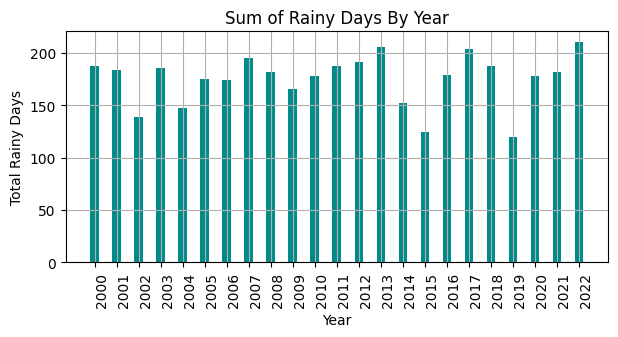

In [13]:
### Gets either the month or the year value to help with calculations based on year or month
def GetDate(data,val):
    vallist=[];
    if val=='year':
        ### Split up the string
     for result in data:
        Date=result.split("-");
        Year=Date[0];
        ### Only get unique values
        if Year not in vallist:
            vallist.append(Year);
    elif val=='month':
        ### Split up the string
        for result in data:
            Date=result.split("-");
            Month=Date[1];
             ### Only get unique values
            if Month not in vallist:
                vallist.append(Month);
    return vallist
### Get the entire list of years since all datasets uses the same timeframe
FullYearList=GetDate(RainfallDaysMonths,'year');
### get the sum of all values by year
def SumValueByYear(data,years,col_name):
    vallist=[];
    for year in years:
        ### Initalize the sum for the year
        final=0;
        for val in data:
            ### Get the year value
            Year=(val['month'].split("-"))[0];
            ### If the year is the same
            if Year==year:
                ### Add it to the sum value for the year
                final+=val[col_name];
        vallist.append(final);
    return vallist
### Get the sum of all the rainfall amount by year
RainfallDaysRecordedList=SumValueByYear(RainfallDaysData,FullYearList,'no_of_rainy_days');
plt.figure(figsize=(7, 3));  # Increase figure size
baramount=np.arange(len(FullYearList));
plt.bar(baramount,RainfallDaysRecordedList,width=0.4,color='darkcyan');
plt.title('Sum of Rainy Days By Year')
plt.ylabel('Total Rainy Days');
plt.xlabel('Year');
plt.xticks(baramount,FullYearList,rotation=90,ha='left');
plt.grid(True);
plt.show();

Answer: The yearly number of rainy days have overall increased from 188 in 2000 to 210 in 2022 even though there is fluctuations between the period.Notably, there has been a sharp increase from 2019 to 2022 as it started from the least rainy days in the year to the most rainy days in the span of just 4 years.Another notable trend is in 2013 to 2015 where the amount of rainy days recorded for the year drastically reduced to around 100 days, which accounts to more than 25% of an entire year.Overall, the graph shows that the total number of rainy days in the years 2000 to 2022 fluctuates considerably, due to varying the number of rainy days of the year in the graph, with the most notable trends showing itself in 2013 to 2015 and 2019 to 2022.

The Dataset below shows the total amount of rain recorded for each month from January 2000 to December 2022

In [14]:
### Print out total rows of data in the file
print(f"There are {RainfallTotalData.shape[0]} rows and {len(RainfallTotalData.dtype.names)} columns in dataset(fiter timeline from 2000 to 2022): {RainfallTotalFile}");
### Print out the number of months of data captured
RainfallTotalMonths=RainfallTotalData['month'];
### Find the total number of months recorded
RainfallTotalMonthslen=len(RainfallTotalMonths);
print(f'There are a total of {RainfallTotalMonthslen} months ranging from {RainfallTotalMonths[0]} to {RainfallTotalMonths[RainfallTotalMonthslen-1]}.');
### Find the max and min amount of rain collected in each month
MaxRainfallAmount=np.max(RainfallTotalData['total_rainfall']);
MinRainfallAmount=np.min(RainfallTotalData['total_rainfall']);
### Corresspond the 2 values above to the month to identify the months where the highest and lowest amount of recorded rainfall
MaxRainfallAmountIndex=np.argmax(RainfallTotalData['total_rainfall']);
MinRainfallAmountIndex=np.argmin(RainfallTotalData['total_rainfall']);
### Find the spread and average of data
StdRainfallAmount=np.std(RainfallTotalData['total_rainfall']);
MeanRainfallAmount=np.mean(RainfallTotalData['total_rainfall']);
### Print out the highest and lowest recorded amount rainfall for the month and also the mean and spread of the data
print(f"The month with the highest amount of rainfall is in the month {RainfallTotalData['month'][MaxRainfallAmountIndex]}, where it rained a total of {MaxRainfallAmount}mm.");
print(f"The month with the lowest amount of rainfall is in the month {RainfallTotalData['month'][MinRainfallAmountIndex]}, where it rained a total of {MinRainfallAmount}mm.");
print(f"The spread of the amount of rainfall in the dataset is {StdRainfallAmount:.5g}mm.");
print(f"The average amount of rainfall recorded is {MeanRainfallAmount:.5g}mm.");

There are 276 rows and 2 columns in dataset(fiter timeline from 2000 to 2022): RainfallMonthlyTotal.csv
There are a total of 276 months ranging from 2000-01 to 2022-12.
The month with the highest amount of rainfall is in the month 2006-12, where it rained a total of 765.9mm.
The month with the lowest amount of rainfall is in the month 2014-02, where it rained a total of 0.2mm.
The spread of the amount of rainfall in the dataset is 113.35mm.
The average amount of rainfall recorded is 179.49mm.


Based on the data for the total amount of rain measured in a month, telling us that the average monthly rainfall recorded is approximately 180mm, where the data can vary by around 115mm.

In order to answer the question:What is the distrubtion of the recorded amount of rainfall for each month? We have to create a histogram in order to answer the question.

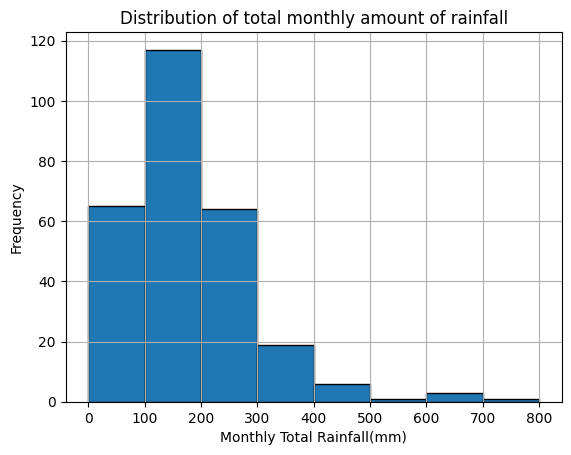

In [15]:
### Finding the distrubution for the monthly total rainfall collected in the years 2000 to 2022
### Bins arrays can create edges of bins in order to make the bin to count the values if it fits the range(e.g. for bins 0 it would show all
### values that are from 0-100, where it then continues for the next subsequent bins)
plt.hist(RainfallTotalData['total_rainfall'],bins=[0,100,200,300,400,500,600,700,800],edgecolor='black');
plt.title('Distribution of total monthly amount of rainfall');
plt.xlabel('Monthly Total Rainfall(mm)');
plt.ylabel('Frequency');
plt.grid(True);
plt.show();

Answer: From the histogram above, we can see that the monthly rainfall that ranges from 100mm to 200mm is the most frequent, followed by the ranges of both 0mm to 100mm and 200mm to 300mm, where they are very similar in terms of frequency.Finally, both 500mm to 600mm and 700mm to 800mm appear the least frequent, followed by 600mm to 700mm, which appeared slightly more often.We can clearly see from the graph above that it is positively skewed, telling us that majority of the rainfall collected for the month is less than the average rainfall collected compared to the months where the rainfall collected is bigger the average appears less often.

After analyzing the data for the total monthly rainfall recorded and the number of rainy days recorded in a month from 2000 to 2022, we should then find the relationship between these 2 datasets with the use of a scatter graph, with a more direct question in order to find out below: What is the relationship between the amount of rainy days compared to the total amount of rainfall in each month?

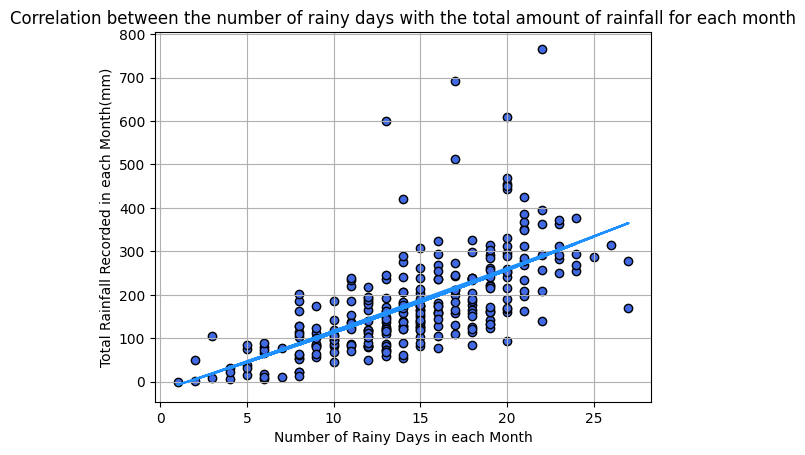

In [16]:
plt.scatter(RainfallDaysData['no_of_rainy_days'],RainfallTotalData['total_rainfall'],color='royalblue',edgecolors='black');
plt.title('Correlation between the number of rainy days with the total amount of rainfall for each month');
plt.xlabel('Number of Rainy Days in each Month');
plt.ylabel('Total Rainfall Recorded in each Month(mm)');
# Calculate trendline
z=np.polyfit(RainfallDaysData['no_of_rainy_days'],RainfallTotalData['total_rainfall'],2);
p=np.poly1d(z);
# Add trendline
plt.plot(RainfallDaysData['no_of_rainy_days'],p(RainfallDaysData['no_of_rainy_days']),color='dodgerblue');
plt.grid(True);
plt.show();

Answer: From the graph, we can observe that there is a positive correlation, as the number of rainy days for the month increase, the total amount of rainfall collected for the same month also increases.What is interesting is that the trendline is very linear despite the fact that it is in fact a quadratic line in order to more accurately see how the correlation changes over time,but it doesnt show any noticable changes to the line, telling us that the change is steadily increasing.Despite this, there are a few outliers such as in 2004-01 where it only rained for 13 days, which is less than half of the month but recorded the 4th highest amount of rainfall for all months and in 2018-11 where it has rained for 27 days, which is almost the whole month, but only recorded around 175mm of rainfall, which is less than the average rainfall recorded being 179.49mm.

The Dataset below shows the relative average humidity levels for each month from January 2000 to December 2022

In [17]:
### Print out the total rows of data in the file
print(f'There are {HumidityMeanData.shape[0]} rows and and{len(HumidityMeanData.dtype.names)} columns in dataset(filter timeline from 2000 to 2022): {HumidityMeanFile}');
### Print out the number of months of data captured
HumidityMeanMonths=HumidityMeanData['month'];
### Find the total number of months recorded 
HumidityMeanMonthslen=len(HumidityMeanMonths);
print(f'There are a total of {HumidityMeanMonthslen} months ranging from {HumidityMeanMonths[0]} to {HumidityMeanMonths[HumidityMeanMonthslen-1]}.');
### Find the max and min of relative mean humidity in each month
MaxHumidityMean=np.max(HumidityMeanData['mean_rh']);
MinHumidityMean=np.min(HumidityMeanData['mean_rh']);
### Correspond the 2 values above to the month to identify the months where the highest and lowest relative average of humidity
MaxHumidityMeanIndex=np.argmax(HumidityMeanData['mean_rh']);
MinHumidityMeanIndex=np.argmin(HumidityMeanData['mean_rh']);
### Find the spread and average of data
StdHumidityMean=np.std(HumidityMeanData['mean_rh']);
MeanHumidityMean=np.mean(HumidityMeanData['mean_rh']);
print(f"The month with the highest relative humidity level is {HumidityMeanData['month'][MaxHumidityMeanIndex]}, where it is recorded a level of {MaxHumidityMean}%.");
print(f"The month with the lowest relatvie humidity level is {HumidityMeanData['month'][MinHumidityMeanIndex]}, where it is recorded a level of {MinHumidityMean}%.");
print(f"The spread of the relative humidity levels is {StdHumidityMean:.3g}%.");
print(f"The overall average humidity level is {MeanHumidityMean:.4g}%.");

There are 276 rows and and2 columns in dataset(filter timeline from 2000 to 2022): RelativeHumidityMonthlyMean.csv
There are a total of 276 months ranging from 2000-01 to 2022-12.
The month with the highest relative humidity level is 2002-12, where it is recorded a level of 88.7%.
The month with the lowest relatvie humidity level is 2016-10, where it is recorded a level of 72.0%.
The spread of the relative humidity levels is 3.74%.
The overall average humidity level is 81.54%.


Based on the data for the average relative humidity for each month, we can see that the overall average humidity level is at around 81%, where there is relatively low variation in the data as it can vary by less than 4%.

After getting the analysis from the data above, it is time to answer the second-last question of the whole project, where we are going to use a pie chart to get our observation: Where does the relative humidity for all the months fall into different categories?

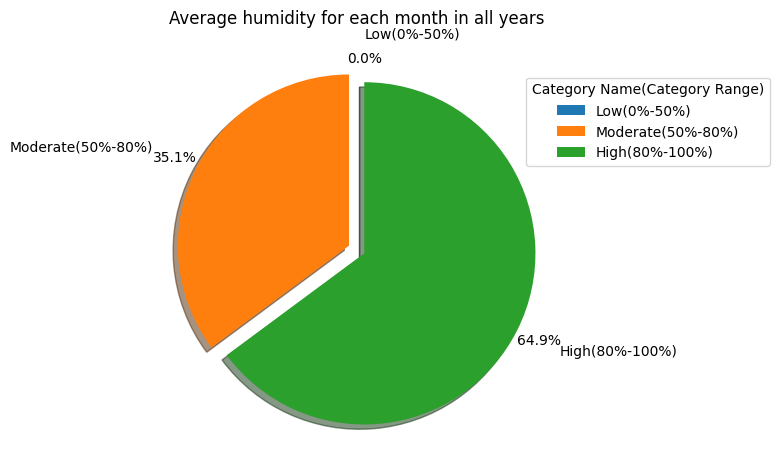

In [18]:
label=['Low(0%-50%)','Moderate(50%-80%)','High(80%-100%)'];
label_value=[0,0,0];
# Highlight one slice of the pie chart
exp=(0,0.1,0);
# this will properly calculate the category values in order to be plotted into a pie chart
for val in HumidityMeanData['mean_rh']:
    if val<50:
        label_value[0]+=1;
    elif val>=50 and val<80:
        label_value[1]+=1;
    else:
        label_value[2]+=1;
# Create Pie-Chart
fig,ax=plt.subplots(figsize=(7, 5)); # Increase figure size
ax.pie(label_value,explode=exp,labels=label,autopct='%1.1f%%',pctdistance=1.14,labeldistance=1.28,shadow=True, startangle=90);
ax.axis('equal');
plt.title('Average humidity for each month in all years',pad=24);
# Shifts the legend so that it is more clearly visible
legend=plt.legend(title='Category Name(Category Range)',bbox_to_anchor=(0.8,0.7));
plt.show();

Answer: From the pie chart, we can see that almost 65% of the mean monthly humidity levels recorded is more than 80%, followed by approximately 35% where humidity levels fall in the range of 50% to 80% which accounts for the remainder of the pie chart, with no recorded month where its monthly mean humidity level reached below 50%.This tells us that the weather from the year 2000 to 2022 is very humid, where not once does the mean humidity levels for any month is below 50%.

The Dataset below shows the average of air temperature for each month from January 2000 to December 2022

In [19]:
### Print out total rows of data in the file
print(f"There are {TemperatureMeanData.shape[0]} rows and {len(TemperatureMeanData.dtype.names)} columns in the dataset(filter timeline 2000 to 2022): {TemperatureMeanFile}");
### Print out the number of months of data captured
TemperatureMeanMonths=TemperatureMeanData['month'];
### Find out the total number of months recorded
TemperatureMeanMonthslen=len(TemperatureMeanMonths);
print(f"There are a total of {TemperatureMeanMonthslen} months ranging from {TemperatureMeanMonths[0]} to {TemperatureMeanMonths[TemperatureMeanMonthslen-1]}.");
### Find the max and min average air temperature in each month
MaxTemperatureMean=np.max(TemperatureMeanData['mean_temp']);
MinTemperatureMean=np.min(TemperatureMeanData['mean_temp']);
### Correspond the 2 values above to the month to identify which month has the highest and lowest mean air temperature
MaxTemperatureMeanIndex=np.argmax(TemperatureMeanData['mean_temp']);
MinTemperatureMeanIndex=np.argmin(TemperatureMeanData['mean_temp']);
### Find the spread and average of data
StdTemperatureMean=np.std(TemperatureMeanData['mean_temp']);
MeanTemperatureMean=np.mean(TemperatureMeanData['mean_temp']);
### Print out the highest and lowest recorded average air temperature for the month and also the mean and spread of the data
print(f"The month with the highest monthly mean surface air temperature is in the month {TemperatureMeanData['month'][MaxTemperatureMeanIndex]}, where it recorded a temperature of {MaxTemperatureMean}°C.");
print(f"The month with the least monthly mean surface air temperature is in the month {TemperatureMeanData['month'][MinTemperatureMeanIndex]}, where it recorded a temperature of {MinTemperatureMean}°C.");
print(f"The spread of the surface air temperature is {StdTemperatureMean:.2g}°C.");
print(f"The overall average surface air temperature is {MeanTemperatureMean:.4g}°C.")

There are 276 rows and 2 columns in the dataset(filter timeline 2000 to 2022): SurfaceAirTemperatureMonthlyMean.csv
There are a total of 276 months ranging from 2000-01 to 2022-12.
The month with the highest monthly mean surface air temperature is in the month 2016-04, where it recorded a temperature of 29.4°C.
The month with the least monthly mean surface air temperature is in the month 2021-01, where it recorded a temperature of 26.0°C.
The spread of the surface air temperature is 0.72°C.
The overall average surface air temperature is 27.86°C.


Based on the data for the average monthly surface air temperature for each month, we can see that the overall average temperature is almost 28°C, where there is really low variation in the data as it can vary by less than 1°C, indicating that the temperature range is stable throughout the year.

After analyzing the data for both average relative humidity levels and average surface air temperature for each month, it is time to answer the last question in the project, where we will be using a line graph to help us out: Does higher humidity levels lead to increased Surface Air Temperature in each month?

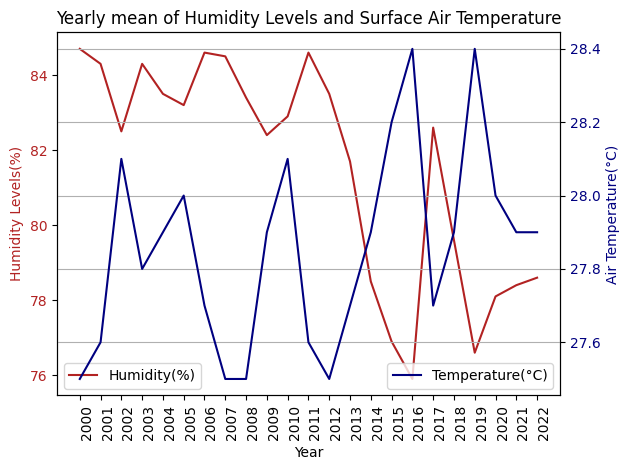

In [20]:
### Calculates average of any data by year
def MeanValueByYear(data,years,col_name):
    vallist=[];
    for year in years:
        ### Initalize the sum value and count to find the average
        final=0;
        count=0;
        for val in data:
         year_val=(val['month'].split("-"))[0];
         if year_val==year:
             final+=val[col_name];
             count+=1;
        vallist.append(final/count);
    return np.round(vallist,decimals=1)
YearlyMeanHumidity=MeanValueByYear(HumidityMeanData,FullYearList,'mean_rh');
YearlyMeanTemperature=MeanValueByYear(TemperatureMeanData,FullYearList,'mean_temp');
## Create differnt axes in one figure
fig,ax1=plt.subplots();
ax1.set_xlabel('Year');
ax1.set_ylabel('Humidity Levels(%)',color='firebrick');
ax1.plot(FullYearList,YearlyMeanHumidity,color='firebrick',label='Humidity(%)');
ax1.tick_params(axis='y',labelcolor='firebrick');
ax1.set_xticks(np.arange(len(FullYearList)));
ax1.set_xticklabels(FullYearList,rotation=90,ha='left');
ax2=ax1.twinx(); # Create another y-axis that shares the same x-axis
ax2.set_ylabel('Air Temperature(°C)',color='navy');
ax2.plot(FullYearList,YearlyMeanTemperature,color='navy',label='Temperature(°C)');
ax2.tick_params(axis='y',labelcolor='navy');
plt.title('Yearly mean of Humidity Levels and Surface Air Temperature');
# Adding legends for both axes
ax1.legend(loc='lower left');
ax2.legend(loc='lower right');
fig.tight_layout();
plt.grid(True);

Answer: After calculating the average for both surface air temperature and humidity levels on a yearly basic, we can see a clear observation that there is a clear correlation between them, as from 2012 to 2016, as humidity levels decreased from 83.5% to 75.9%, the surface air temperature instead increased from 27.5°C to 28.4°C.In addition,from 2019 to 2022, humidity levels increased from 76.6% to 78.6%, the surface air temperature decreases from 28.4°C to 27.9°C.We can then conclude that higher humidity levels does not lead to increased surface air temperature but leads to lower surface air temperature.

From the graphs shown, we can see that the number of days have increased over time from 2000 to 2022 despite alot of flunctuations, the range of total monthly rainfall where it appeared the most often is 100mm to 200mm, when the number of rainy days for the month increase, the total amount of rainfall for the month also increases steadily with no noticable changes over time, that majority of the timeline has recorded a very high amount of humidity levels, and finally that increased humidity doesn't lead to increased surfacea air temperature but in fact the opposite. We have therefore concluded all the questions answered with a graph using matplotlib, with supporting summarization of data using numpy.